In [1]:
DATA = '../data/'
FIGS = '../results/figures/'
CACHE = '../f1_cache'

In [2]:
import pandas as pd

raw = pd.read_pickle(DATA + 'laps_raw.pkl') # select the raw lap data file to read

# LOOK BEFORE YOU FILTER. Compound naming varies by season - confirm what you are dropping
print(raw['Compound'].value_counts(dropna=False), "\n")
print("TrackStatus dtype:", raw['TrackStatus'].dtype, "\n") # must be object/string, or the '1' test silently matches nothing

# clean the data to only keep laps that are:
df = raw[
    raw['IsAccurate'] & # actual racing laps unaffected by pit lane etc
    (raw['TrackStatus'] == '1') & # laps raced under the green flag
    raw['LapTime'].notna() & # have available lap times data
    raw['Compound'].notna() & # have available compounds data
    raw['TyreLife'].notna() # have available tyre life data
].copy()

df = df[~df['Compound'].isin(['INTERMEDIATE', 'WET'])].copy() # .copy() or the relabel below warns
df['LapSeconds'] = df['LapTime'].dt.total_seconds()

# Circuits whose LAYOUT changed inside the training window: same label, two different tracks.
LAYOUT_CHANGED = [
    (2022, 'Barcelona'), # final chicane removed for 2023. Only relevant if you collected 2022
    (2022, 'Marina Bay'), # 4 corners removed for 2023 onwards
]

# Rename any track layout inside LAYOUT_CHANGED so model can't read it
# removes it from training, but doesn't delete it
for yr, ckt in LAYOUT_CHANGED:
    m = (df['Year'] == yr) & (df['Circuit'] == ckt)
    df.loc[m, 'Circuit'] = f'{ckt}_pre{yr + 1}'
    print(f"relabelled {m.sum()} laps: {ckt} {yr} -> {ckt}_pre{yr + 1}")

med = df.groupby(['Year', 'Round', 'Driver'])['LapSeconds'].transform('median')
df = df[df['LapSeconds'] < med * 1.07]

df['RaceID'] = df['Year'].astype(str) + '_' + df['Round'].astype(str)

cols = ['LapSeconds', 'TyreLife', 'LapNumber', 'Compound', 'Circuit',
        'Driver', 'Team', 'AirTemp', 'TrackTemp', 'FreshTyre',
        'RaceID', 'Year', 'Round']

# dropna() below kills a row if ANY of these 13 columns is missing.
# A failed weather join makes AirTemp/TrackTemp NaN for a whole race, which would
# delete that race silently. Look at what is missing BEFORE dropping it.
print("nulls per column:\n", df[cols].isna().sum()[lambda x: x > 0], "\n")

races_before = df['RaceID'].nunique()
df = df[cols].dropna()
races_after = df['RaceID'].nunique()

df.to_pickle(DATA + 'laps_clean.pkl')
print(f"{len(raw)} raw -> {len(df)} clean ({len(df)/len(raw):.0%} kept)")
print(f"races: {races_before} -> {races_after}")
if races_after < races_before:
    print("WARNING: dropna() removed whole races. Check the nulls above before continuing.")
print(df['Compound'].value_counts())

Compound
HARD            44357
MEDIUM          36901
SOFT            12761
INTERMEDIATE     5945
WET               461
nan               446
None              426
Name: count, dtype: int64 

TrackStatus dtype: object 

relabelled 1060 laps: Barcelona 2022 -> Barcelona_pre2023
relabelled 275 laps: Marina Bay 2022 -> Marina Bay_pre2023
nulls per column:
 Lap([], dtype: int64) 

101297 raw -> 79382 clean (78% kept)
races: 90 -> 90
Compound
HARD      38503
MEDIUM    30836
SOFT       9986
None         57
Name: count, dtype: int64


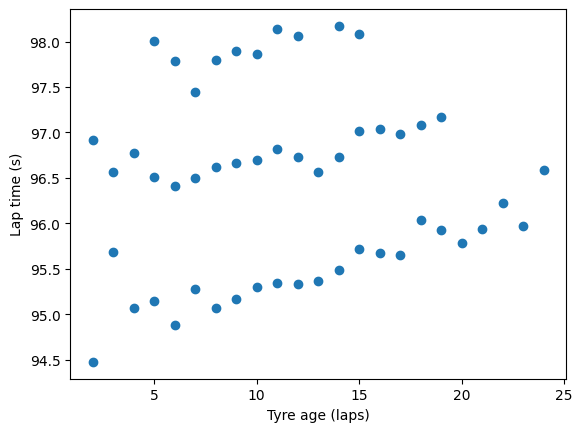

In [3]:
import matplotlib.pyplot as plt

stint = df[(df['RaceID'] == '2024_1') & (df['Driver'] == 'NOR')]
assert len(stint) > 0, "no laps matched - pick a RaceID and Driver that exist in df"
plt.scatter(stint['TyreLife'], stint['LapSeconds'])
plt.xlabel('Tyre age (laps)'); plt.ylabel('Lap time (s)')
plt.show()

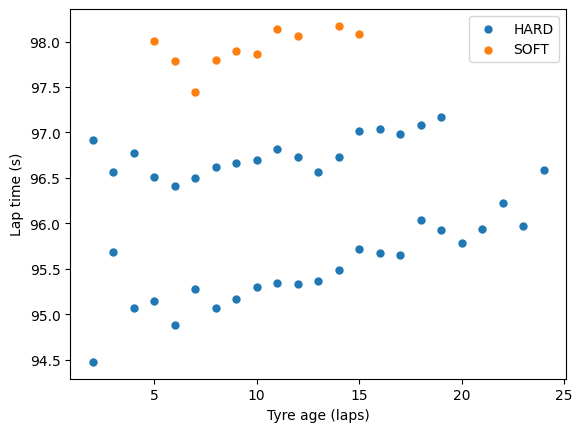

In [4]:
for c, g in stint.groupby('Compound'):
    plt.scatter(g['TyreLife'], g['LapSeconds'], label=c, s=25)
plt.xlabel('Tyre age (laps)'); plt.ylabel('Lap time (s)'); plt.legend()
plt.show()

In [5]:
med = df.groupby(['Circuit', 'Year'])['LapSeconds'].median().unstack()
delta = med.diff(axis=1)           # each circuit's change from the previous year
trend = delta.median()             # what every circuit did that year - regulations, tyres
anomaly = delta.sub(trend, axis=1) # what THIS circuit did beyond that

print("Lap time change beyond the season-wide trend (seconds):")
print(anomaly.round(1).dropna(how='all').to_string())

flagged = anomaly[anomaly.abs() > 1.5].stack() # 1.5s is a starting point, not a rule
if len(flagged):
    print("\nWorth investigating:\n", flagged.round(1).to_string())

Lap time change beyond the season-wide trend (seconds):
Year               2022  2023  2024  2025
Circuit                                  
Austin              NaN   0.2  -1.6   0.5
Baku                NaN  -1.5   2.3  -2.5
Barcelona           NaN   NaN   1.1   0.9
Budapest            NaN   0.8   0.4  -1.6
Imola               NaN   NaN   NaN   0.1
Jeddah              NaN   1.0  -0.5   0.8
Las Vegas           NaN   NaN   0.3  -1.9
Lusail              NaN   NaN  -1.6   0.5
Marina Bay          NaN   NaN  -1.3  -0.1
Melbourne           NaN  -0.9   0.6   3.0
Mexico City         NaN   0.8  -1.3   1.1
Miami               NaN  -1.1   0.8   NaN
Monaco              NaN   0.8   1.6  -1.9
Montréal            NaN  -0.4   1.6  -1.2
Monza               NaN   0.8  -1.5  -0.8
Sakhir              NaN  -0.0  -0.9   2.1
Shanghai            NaN   NaN   NaN  -3.4
Silverstone         NaN  -0.0  -0.2  -0.3
Spa-Francorchamps   NaN  -0.6  -3.2  -1.0
Spielberg           NaN   0.0   1.2   0.1
Suzuka              